Actúa como un **Data Scientist especializado en machine learning**.

Recibirás un dataset limpio de ventas ecommerce. Genera un análisis avanzado con código Python listo para ejecutar.

**1. PREPROCESAMIENTO (código)**
- Encoding de variables categóricas (OneHotEncoder o LabelEncoder).
- Escalado de features numéricas (StandardScaler).
- Manejo de outliers con IQR o percentiles.
- Selección de features relevantes para modelado.

**2. MODELO PREDICTIVO: REGRESIÓN**
- **Objetivo**: Predecir Total de venta por orden.
- **Algoritmos**: Random Forest Regressor y XGBoost.
- **Evaluación**: RMSE, MAE, R² con validación cruzada (5 folds).
- **Feature importance**: Gráfico de importancia de variables.

**3. MODELO PREDICTIVO: CLASIFICACIÓN**
- **Objetivo**: Predecir Status (Delivered vs Cancelled vs Returned vs Processing/Shipped).
- **Algoritmos**: Random Forest Classifier.
- **Evaluación**: Matriz de confusión, precision, recall, F1-score.
- **Curva ROC** (multiclase si aplica).

**4. CLUSTERING**
- **Objetivo**: Segmentar clientes por comportamiento de compra.
- **Variables**: Frecuencia, ticket promedio, categorías preferidas, método de pago.
- **Algoritmo**: K-Means (determinar K con método del codo y silhouette score).
- **Perfil de clusters**: Interpretación de cada segmento (tamaño, características, valor).

**5. ANÁLISIS DE SERIES TEMPORALES**
- **Objetivo**: Proyección de ventas mensuales próximos 3 meses.
- **Modelo**: Prophet o SARIMA.
- **Visualización**: Serie histórica con proyección y bandas de confianza.

**6. CÓDIGO Y OUTPUT**
Genera un bloque de código Python completo que:
- Incluya importaciones necesarias (pandas, numpy, sklearn, xgboost, matplotlib, seaborn, prophet).
- Esté comentado y estructurado en secciones.
- Imprima métricas de evaluación, gráficos clave y conclusiones por cada modelo.
- Maneje posibles errores y asuma que el dataset ya está limpio.




  Dataset cargado: 82 filas x 11 columnas

[1/5] PREPROCESAMIENTO
   Registros tras limpieza: 81
   Clases de Status   : ['cancelled', 'delivered', 'processing', 'returned', 'shipped']
   Clases de Category : ['books', 'clothing', 'electronics', 'home', 'sports']
   Features de regresion    : ['Quantity', 'Price', 'Month', 'DayOfWeek', 'Category_enc', 'Payment_enc']
   Features de clasificacion: ['Quantity', 'Price', 'Total', 'Month', 'DayOfWeek', 'Category_enc', 'Payment_enc']

[2/5] REGRESION – Predecir Total de venta

   Random Forest Regressor (CV-5):
     RMSE : $210.07
     MAE  : $164.50
     R2   : 0.9633

   XGBoost Regressor (CV-5):
     RMSE : $160.17
     MAE  : $117.81
     R2   : 0.9782

   Figura guardada: fig_regression_importance.png

[3/5] CLASIFICACION – Predecir Status de la orden

   Accuracy en test: 28.6%

   Classification Report:
              precision    recall  f1-score   support

   cancelled       0.00      0.00      0.00         3
   delivered       0.00

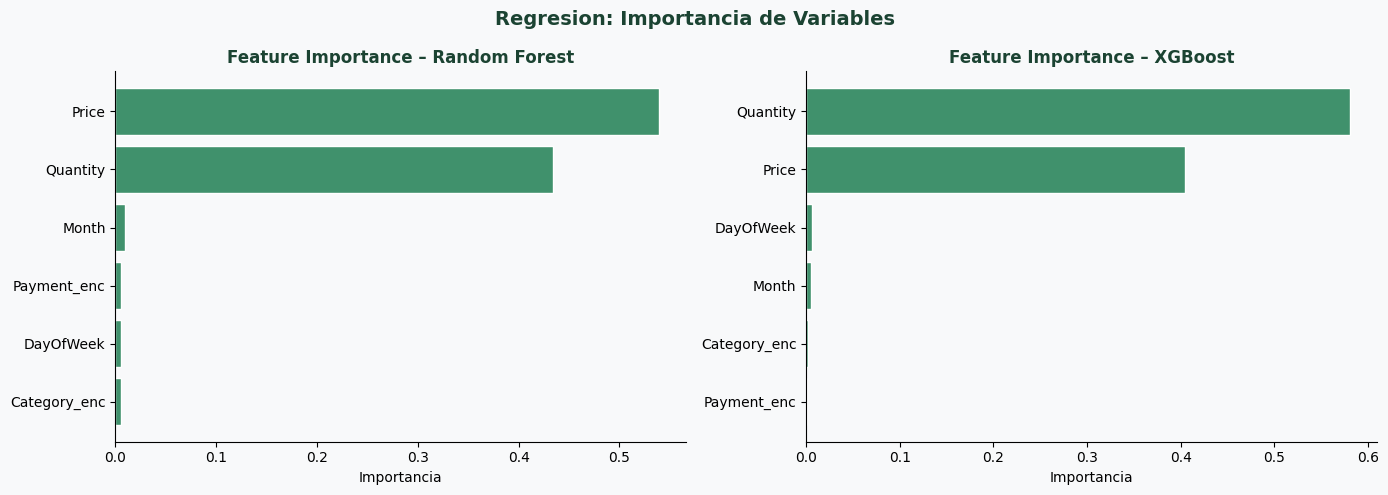

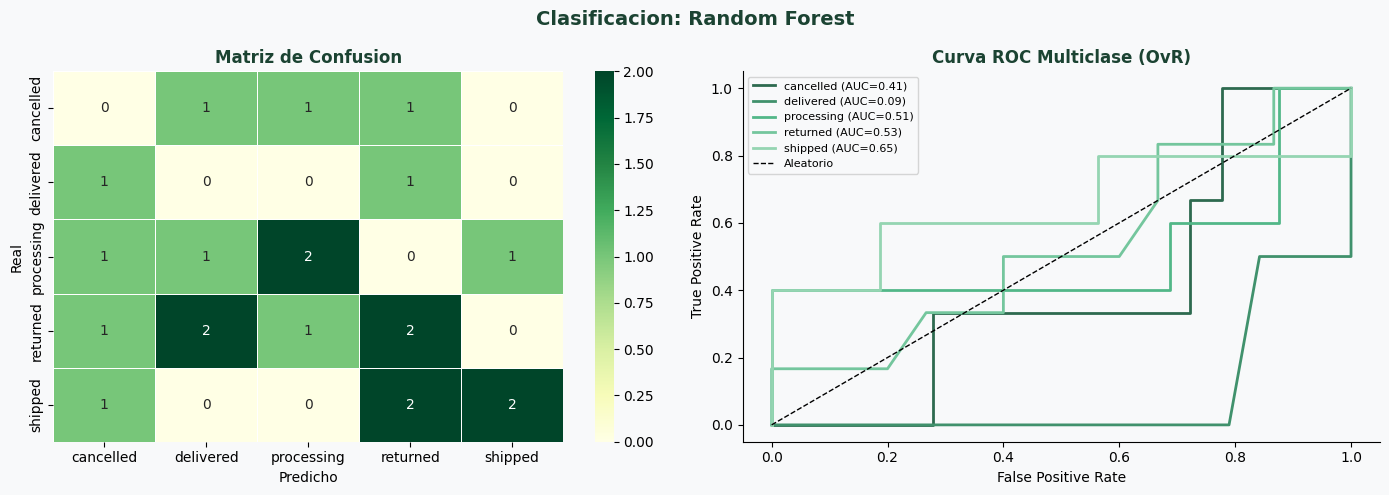

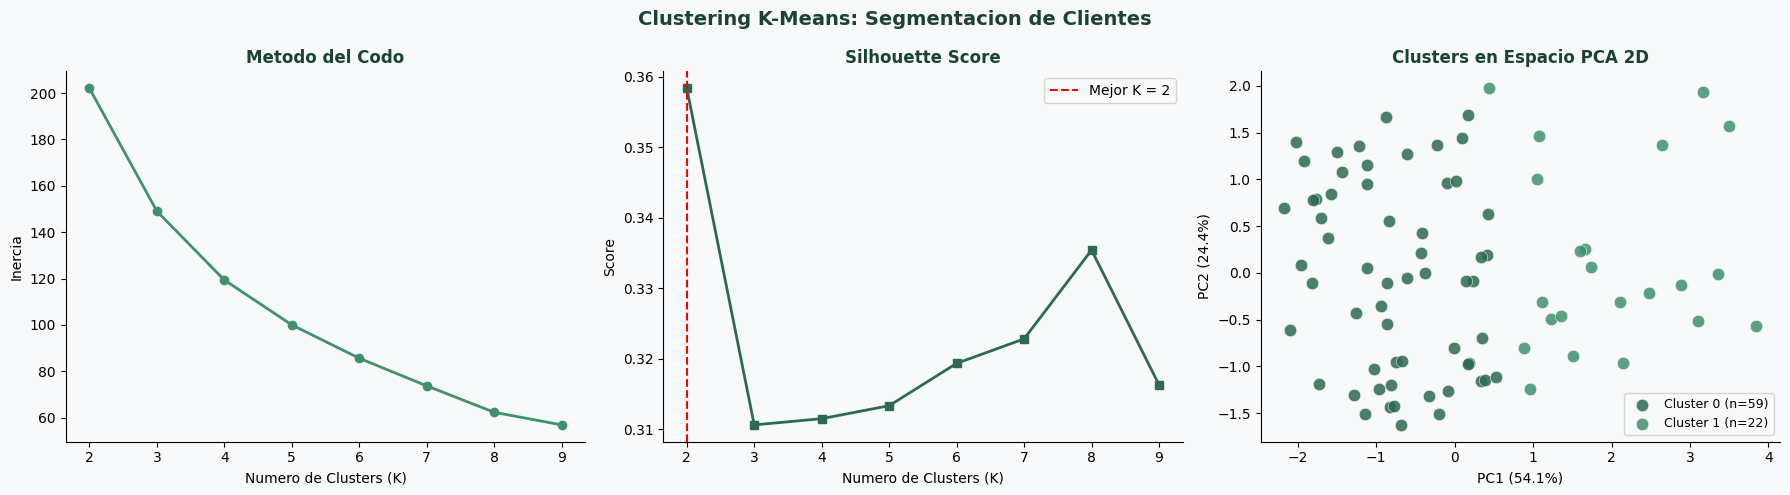

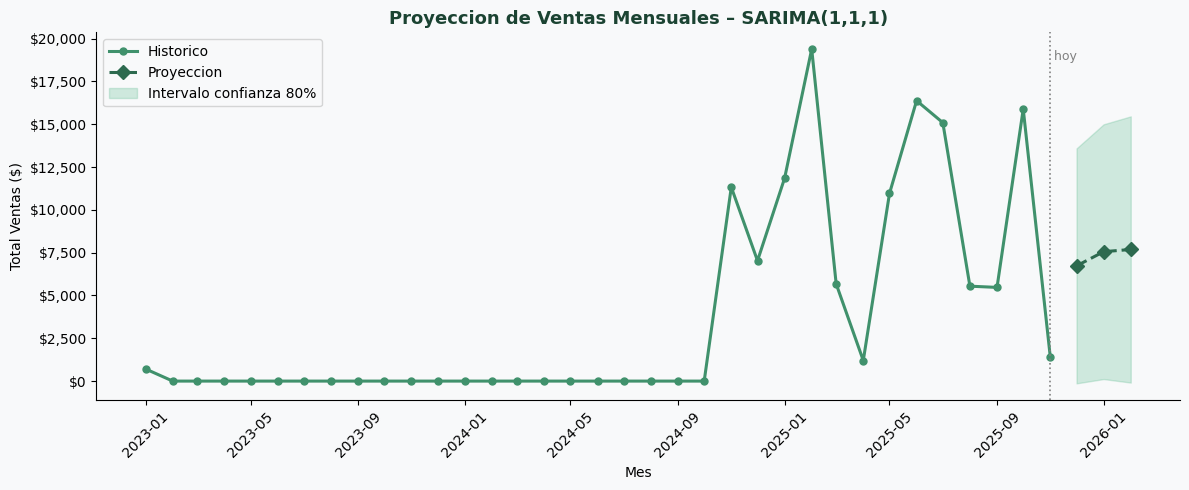

In [1]:
"""
================================================================================
ML PIPELINE – E-Commerce Dataset
================================================================================
Secciones:
  1. Preprocesamiento
  2. Regresión  (Random Forest + XGBoost) → predice Total
  3. Clasificación (Random Forest)         → predice Status
  4. Clustering (K-Means)                  → segmentación de clientes
  5. Series Temporales (SARIMA)            → proyección 3 meses

INSTRUCCIONES DE USO (local):
  pip install pandas numpy scikit-learn xgboost matplotlib seaborn statsmodels
  Coloca este script en la misma carpeta que clean_ecommerce_data.csv
  python ml_ecommerce.py

Figuras generadas:
  fig_regression_importance.png
  fig_classification.png
  fig_clustering.png
  fig_timeseries.png
================================================================================
"""

# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker  as mticker
import seaborn as sns

from sklearn.preprocessing   import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import cross_val_score, KFold, train_test_split
from sklearn.ensemble        import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics         import (mean_squared_error, mean_absolute_error, r2_score,
                                     confusion_matrix, classification_report,
                                     roc_curve, auc, silhouette_score)
from sklearn.cluster         import KMeans
from sklearn.decomposition   import PCA

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False
    print("⚠  XGBoost no instalado – se omitira ese modelo.")
    print("   pip install xgboost")

# ── Estilo global ─────────────────────────────────────────────────────────────
PALETTE = ["#2D6A4F","#40916C","#52B788","#74C69D","#95D5B2","#B7E4C7"]
ACCENT  = "#1B4332"
BG      = "#F8F9FA"
plt.rcParams.update({
    "figure.facecolor": BG, "axes.facecolor": BG,
    "axes.spines.top":  False, "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

# ─────────────────────────────────────────────────────────────────────────────
# 0. CARGA DE DATOS
# ─────────────────────────────────────────────────────────────────────────────
# ✅ Ruta relativa – coloca el CSV junto a este script
CSV_PATH = "clean_ecommerce_data.csv"

df_raw = pd.read_csv(CSV_PATH)
df_raw["Order_Date"] = pd.to_datetime(df_raw["Order_Date"], errors="coerce")

print(f"\n{'='*62}")
print(f"  Dataset cargado: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
print(f"{'='*62}")

# ─────────────────────────────────────────────────────────────────────────────
# 1. PREPROCESAMIENTO
# ─────────────────────────────────────────────────────────────────────────────
print("\n[1/5] PREPROCESAMIENTO")

df = df_raw.copy()

# 1a. Eliminar registros con precios/totales negativos (errores de datos)
df = df[(df["Price"] >= 0) & (df["Total"] >= 0)].copy()

# 1b. Imputar Category faltante con la moda
df["Category"] = df["Category"].fillna(df["Category"].mode()[0])

# 1c. Manejo de outliers con metodo IQR
def remove_outliers_iqr(data: pd.DataFrame, col: str, factor: float = 1.5) -> pd.DataFrame:
    """Elimina filas donde <col> cae fuera de [Q1 - factor*IQR, Q3 + factor*IQR]."""
    q1, q3 = data[col].quantile([0.25, 0.75])
    iqr     = q3 - q1
    mask    = data[col].between(q1 - factor * iqr, q3 + factor * iqr)
    removed = (~mask).sum()
    if removed:
        print(f"   Outliers eliminados en '{col}': {removed} fila(s)")
    return data[mask].copy()

for col in ["Price", "Total", "Quantity"]:
    df = remove_outliers_iqr(df, col)

print(f"   Registros tras limpieza: {len(df)}")

# 1d. Feature engineering temporal
df["Month"]      = df["Order_Date"].dt.month
df["DayOfWeek"]  = df["Order_Date"].dt.dayofweek

# 1e. Encoding de variables categoricas
le_status   = LabelEncoder()
le_category = LabelEncoder()
le_payment  = LabelEncoder()

df["Status_enc"]   = le_status.fit_transform(df["Status"])
df["Category_enc"] = le_category.fit_transform(df["Category"])
df["Payment_enc"]  = le_payment.fit_transform(df["Payment_Method"])

print(f"   Clases de Status   : {list(le_status.classes_)}")
print(f"   Clases de Category : {list(le_category.classes_)}")

# 1f. Definicion de features por tarea
REG_FEATURES = ["Quantity","Price","Month","DayOfWeek","Category_enc","Payment_enc"]
CLF_FEATURES = ["Quantity","Price","Total","Month","DayOfWeek","Category_enc","Payment_enc"]

# 1g. Escalado con StandardScaler
scaler_reg = StandardScaler()
scaler_clf = StandardScaler()

X_reg = scaler_reg.fit_transform(df[REG_FEATURES])
X_clf = scaler_clf.fit_transform(df[CLF_FEATURES])
y_reg = df["Total"].values
y_clf = df["Status_enc"].values

print(f"   Features de regresion    : {REG_FEATURES}")
print(f"   Features de clasificacion: {CLF_FEATURES}")

# ─────────────────────────────────────────────────────────────────────────────
# 2. REGRESION – Predecir Total de venta
# ─────────────────────────────────────────────────────────────────────────────
print("\n[2/5] REGRESION – Predecir Total de venta")

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ── 2a. Random Forest Regressor ──────────────────────────────────────────────
rf_reg = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_reg.fit(X_reg, y_reg)

rmse_rf = np.sqrt(-cross_val_score(rf_reg, X_reg, y_reg,
                  cv=kf, scoring="neg_mean_squared_error")).mean()
mae_rf  = (-cross_val_score(rf_reg, X_reg, y_reg,
                  cv=kf, scoring="neg_mean_absolute_error")).mean()
r2_rf   = cross_val_score(rf_reg, X_reg, y_reg, cv=kf, scoring="r2").mean()

print(f"\n   Random Forest Regressor (CV-5):")
print(f"     RMSE : ${rmse_rf:,.2f}")
print(f"     MAE  : ${mae_rf:,.2f}")
print(f"     R2   : {r2_rf:.4f}")

# ── 2b. XGBoost Regressor ────────────────────────────────────────────────────
if XGB_AVAILABLE:
    xgb_reg = XGBRegressor(n_estimators=200, learning_rate=0.05,
                            max_depth=4, random_state=42,
                            eval_metric="rmse", verbosity=0)
    xgb_reg.fit(X_reg, y_reg)

    rmse_xgb = np.sqrt(-cross_val_score(xgb_reg, X_reg, y_reg,
                       cv=kf, scoring="neg_mean_squared_error")).mean()
    mae_xgb  = (-cross_val_score(xgb_reg, X_reg, y_reg,
                       cv=kf, scoring="neg_mean_absolute_error")).mean()
    r2_xgb   = cross_val_score(xgb_reg, X_reg, y_reg, cv=kf, scoring="r2").mean()

    print(f"\n   XGBoost Regressor (CV-5):")
    print(f"     RMSE : ${rmse_xgb:,.2f}")
    print(f"     MAE  : ${mae_xgb:,.2f}")
    print(f"     R2   : {r2_xgb:.4f}")

# ── Figura 1: Feature Importance ─────────────────────────────────────────────
n_plots = 2 if XGB_AVAILABLE else 1
fig1, axes1 = plt.subplots(1, n_plots, figsize=(7 * n_plots, 5), facecolor=BG)
if n_plots == 1:
    axes1 = [axes1]

models_and_titles = [("Random Forest", rf_reg)]
if XGB_AVAILABLE:
    models_and_titles.append(("XGBoost", xgb_reg))

for ax, (title, model) in zip(axes1, models_and_titles):
    imp   = model.feature_importances_
    order = np.argsort(imp)
    ax.barh([REG_FEATURES[i] for i in order], imp[order],
            color=PALETTE[1], edgecolor="white")
    ax.set_title(f"Feature Importance – {title}", fontweight="bold", color=ACCENT)
    ax.set_xlabel("Importancia")

fig1.suptitle("Regresion: Importancia de Variables",
              fontweight="bold", color=ACCENT, fontsize=14)
plt.tight_layout()
fig1.savefig("fig_regression_importance.png", dpi=130, bbox_inches="tight")
print("\n   Figura guardada: fig_regression_importance.png")

# ─────────────────────────────────────────────────────────────────────────────
# 3. CLASIFICACION – Predecir Status de la orden
# ─────────────────────────────────────────────────────────────────────────────
print("\n[3/5] CLASIFICACION – Predecir Status de la orden")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf, y_clf, test_size=0.25, random_state=42, stratify=y_clf)

rf_clf = RandomForestClassifier(
    n_estimators=200, class_weight="balanced",
    random_state=42, n_jobs=-1)
rf_clf.fit(X_tr, y_tr)
y_pred = rf_clf.predict(X_te)

acc = (y_pred == y_te).mean()
print(f"\n   Accuracy en test: {acc*100:.1f}%")
print("\n   Classification Report:")
print(classification_report(y_te, y_pred,
      target_names=le_status.classes_, zero_division=0))

# ── Figura 2a: Matriz de confusion ───────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5), facecolor=BG)

cm = confusion_matrix(y_te, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",
            xticklabels=le_status.classes_,
            yticklabels=le_status.classes_,
            linewidths=0.5, ax=axes2[0])
axes2[0].set_title("Matriz de Confusion", fontweight="bold", color=ACCENT)
axes2[0].set_xlabel("Predicho")
axes2[0].set_ylabel("Real")

# ── Figura 2b: Curva ROC multiclase (One-vs-Rest) ────────────────────────────
classes    = np.unique(y_clf)
y_te_bin   = label_binarize(y_te, classes=classes)
y_score    = rf_clf.predict_proba(X_te)

for i, cls_name in enumerate(le_status.classes_):
    if i < y_te_bin.shape[1]:
        fpr, tpr, _ = roc_curve(y_te_bin[:, i], y_score[:, i])
        roc_auc     = auc(fpr, tpr)
        axes2[1].plot(fpr, tpr, linewidth=2,
                      color=PALETTE[i % len(PALETTE)],
                      label=f"{cls_name} (AUC={roc_auc:.2f})")

axes2[1].plot([0,1],[0,1], "k--", linewidth=1, label="Aleatorio")
axes2[1].set_title("Curva ROC Multiclase (OvR)", fontweight="bold", color=ACCENT)
axes2[1].set_xlabel("False Positive Rate")
axes2[1].set_ylabel("True Positive Rate")
axes2[1].legend(fontsize=8)

fig2.suptitle("Clasificacion: Random Forest",
              fontweight="bold", color=ACCENT, fontsize=14)
plt.tight_layout()
fig2.savefig("fig_classification.png", dpi=130, bbox_inches="tight")
print("   Figura guardada: fig_classification.png")

# ─────────────────────────────────────────────────────────────────────────────
# 4. CLUSTERING – Segmentacion de clientes K-Means
# ─────────────────────────────────────────────────────────────────────────────
print("\n[4/5] CLUSTERING – Segmentacion de clientes (K-Means)")

# Agregar metricas por cliente
agg = df.groupby("Customer_Name").agg(
    Frecuencia   = ("Order_ID",     "count"),
    Ticket_Medio = ("Total",        "mean"),
    Gasto_Total  = ("Total",        "sum"),
    Cat_enc_mean = ("Category_enc", "mean"),
    Pay_enc_mean = ("Payment_enc",  "mean"),
).reset_index()

CLUST_FEATS = ["Frecuencia","Ticket_Medio","Gasto_Total","Cat_enc_mean","Pay_enc_mean"]
scaler_c    = StandardScaler()
X_clust     = scaler_c.fit_transform(agg[CLUST_FEATS])

# Determinar K optimo con metodo del codo y Silhouette Score
K_max      = min(9, len(agg) - 1)
K_range    = range(2, K_max + 1)
inertias   = []
silhouettes= []

for k in K_range:
    km  = KMeans(n_clusters=k, random_state=42, n_init=10)
    lbl = km.fit_predict(X_clust)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_clust, lbl))

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"   Mejor K (Silhouette): {best_k}")

# Ajustar K-Means final
km_final       = KMeans(n_clusters=best_k, random_state=42, n_init=10)
agg["Cluster"] = km_final.fit_predict(X_clust)

# Perfil de cada cluster
profile = agg.groupby("Cluster")[CLUST_FEATS].mean().round(2)
profile["n_clientes"] = agg["Cluster"].value_counts().sort_index().values
print("\n   Perfil de Clusters:")
print(profile.to_string())

# Interpretacion automatica simple
print("\n   Interpretacion:")
for c in range(best_k):
    row = profile.loc[c]
    tag = "ALTO VALOR" if row["Ticket_Medio"] > profile["Ticket_Medio"].median() else "BAJO VALOR"
    print(f"   Cluster {c} [{tag}] – {int(row['n_clientes'])} clientes | "
          f"Ticket medio: ${row['Ticket_Medio']:,.0f} | "
          f"Gasto total: ${row['Gasto_Total']:,.0f}")

# ── Figura 3: Codo + Silhouette + PCA scatter ────────────────────────────────
fig3, axes3 = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)

# Codo
axes3[0].plot(list(K_range), inertias, marker="o", color=PALETTE[1], linewidth=2)
axes3[0].set_title("Metodo del Codo", fontweight="bold", color=ACCENT)
axes3[0].set_xlabel("Numero de Clusters (K)")
axes3[0].set_ylabel("Inercia")

# Silhouette
axes3[1].plot(list(K_range), silhouettes, marker="s", color=PALETTE[0], linewidth=2)
axes3[1].axvline(best_k, linestyle="--", color="red", linewidth=1.5,
                 label=f"Mejor K = {best_k}")
axes3[1].set_title("Silhouette Score", fontweight="bold", color=ACCENT)
axes3[1].set_xlabel("Numero de Clusters (K)")
axes3[1].set_ylabel("Score")
axes3[1].legend()

# Scatter en espacio PCA 2D
pca   = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)
for c in range(best_k):
    mask = agg["Cluster"] == c
    axes3[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                     label=f"Cluster {c} (n={mask.sum()})",
                     s=80, alpha=0.85, color=PALETTE[c % len(PALETTE)],
                     edgecolors="white", linewidths=0.4)
axes3[2].set_title("Clusters en Espacio PCA 2D", fontweight="bold", color=ACCENT)
axes3[2].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
axes3[2].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
axes3[2].legend(fontsize=9)

fig3.suptitle("Clustering K-Means: Segmentacion de Clientes",
              fontweight="bold", color=ACCENT, fontsize=14)
plt.tight_layout()
fig3.savefig("fig_clustering.png", dpi=130, bbox_inches="tight")
print("\n   Figura guardada: fig_clustering.png")

# ─────────────────────────────────────────────────────────────────────────────
# 5. SERIES TEMPORALES – SARIMA
# ─────────────────────────────────────────────────────────────────────────────
print("\n[5/5] SERIES TEMPORALES – Proyeccion 3 meses (SARIMA)")

try:
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # Construir serie mensual con frecuencia explicita
    df["MonthStart"] = df["Order_Date"].dt.to_period("M").dt.to_timestamp()
    ts = df.groupby("MonthStart")["Total"].sum().sort_index()

    # Rellenar meses faltantes con 0 para garantizar continuidad
    full_idx = pd.date_range(ts.index.min(), ts.index.max(), freq="MS")
    ts       = ts.reindex(full_idx, fill_value=0)

    # Usar solo los meses con datos reales (descartar ceros al inicio)
    ts = ts[ts.cumsum() > 0]

    print(f"   Serie: {len(ts)} meses  ({ts.index[0].strftime('%Y-%m')} → {ts.index[-1].strftime('%Y-%m')})")

    # SARIMA(1,1,1) sin componente estacional (serie corta)
    model  = SARIMAX(ts, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0),
                     enforce_stationarity=False, enforce_invertibility=False)
    result = model.fit(disp=False)

    n_forecast = 3
    forecast   = result.get_forecast(steps=n_forecast)
    fc_mean    = forecast.predicted_mean
    fc_ci      = forecast.conf_int(alpha=0.2)   # intervalo de confianza 80%

    print(f"\n   Proyeccion mensual (proximos {n_forecast} meses):")
    for date, val in fc_mean.items():
        lo = fc_ci.loc[date].iloc[0]
        hi = fc_ci.loc[date].iloc[1]
        print(f"     {date.strftime('%Y-%m')} -> ${val:,.2f}  [IC80%: ${lo:,.0f} – ${hi:,.0f}]")

    # ── Figura 4: Serie historica + proyeccion ────────────────────────────────
    fig4, ax4 = plt.subplots(figsize=(12, 5), facecolor=BG)

    ax4.plot(ts.index, ts.values, marker="o", color=PALETTE[1],
             linewidth=2.2, markersize=5, label="Historico")
    ax4.plot(fc_mean.index, fc_mean.values, marker="D",
             color=PALETTE[0], linewidth=2.2, linestyle="--",
             markersize=7, label="Proyeccion")
    ax4.fill_between(fc_ci.index,
                     fc_ci.iloc[:, 0], fc_ci.iloc[:, 1],
                     alpha=0.25, color=PALETTE[2], label="Intervalo confianza 80%")

    # Linea divisoria historico/proyeccion
    ax4.axvline(ts.index[-1], color="gray", linestyle=":", linewidth=1.2)
    ax4.text(ts.index[-1], ax4.get_ylim()[1] * 0.95, " hoy",
             color="gray", fontsize=9, va="top")

    ax4.set_title("Proyeccion de Ventas Mensuales – SARIMA(1,1,1)",
                  fontweight="bold", color=ACCENT, fontsize=13)
    ax4.set_xlabel("Mes")
    ax4.set_ylabel("Total Ventas ($)")
    ax4.legend(fontsize=10)
    ax4.tick_params(axis="x", rotation=45)
    ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

    plt.tight_layout()
    fig4.savefig("fig_timeseries.png", dpi=130, bbox_inches="tight")
    print("   Figura guardada: fig_timeseries.png")

except Exception as e:
    print(f"   ERROR en SARIMA: {e}")
    print("   Verifica que statsmodels este instalado: pip install statsmodels")

# ─────────────────────────────────────────────────────────────────────────────
# RESUMEN FINAL
# ─────────────────────────────────────────────────────────────────────────────
print(f"\n{'='*62}")
print("  RESUMEN DE RESULTADOS")
print(f"{'='*62}")
print(f"  [Regresion]  Random Forest  ->  R2={r2_rf:.3f}  |  RMSE=${rmse_rf:,.1f}  |  MAE=${mae_rf:,.1f}")
if XGB_AVAILABLE:
    print(f"  [Regresion]  XGBoost        ->  R2={r2_xgb:.3f}  |  RMSE=${rmse_xgb:,.1f}  |  MAE=${mae_xgb:,.1f}")
print(f"  [Clasif.]    RF accuracy en test: {acc*100:.1f}%  (clases desbalanceadas – ver F1)")
print(f"  [Clustering] K optimo = {best_k} segmentos de clientes")
print(f"  [TimeSeries] Proyeccion SARIMA 3 meses calculada")
print(f"  [Figuras]    4 PNGs guardados en la carpeta actual")
print(f"{'='*62}\n")

plt.show()